In [1]:
!pip install pandas numpy sqlalchemy psycopg2-binary openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [13]:
import pandas as pd
import numpy as np
import unicodedata
import re

from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

In [19]:
ruta_fallecidos = r"C:\Users\CIELO\Desktop\Inteligencia De Negocios\fallecidos_sinadef.csv"
ruta_ubigeo = r"C:\Users\CIELO\Desktop\Inteligencia De Negocios\UBIGEO.xlsx"
ruta_region = r"C:\Users\CIELO\Desktop\Inteligencia De Negocios\tabla_region_departamento.xlsx"

In [21]:
import os
archivos = {
    "Fallecidos SINADEF": ruta_fallecidos,
    "UBIGEO": ruta_ubigeo,
    "Región natural": ruta_region
}

for nombre, ruta in archivos.items():
    if os.path.exists(ruta):
        print(f"{nombre}: archivo encontrado")
    else:
        print(f"{nombre}: NO encontrado -> {ruta}")

Fallecidos SINADEF: archivo encontrado
UBIGEO: archivo encontrado
Región natural: archivo encontrado


In [11]:
import sys
print(sys.executable)
!{sys.executable} -m pip install --upgrade sqlalchemy psycopg2-binary

C:\ProgramData\anaconda3\python.exe
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------  2.1/2.1 MB 68.0 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 34.5 MB/s eta 0:00:00


In [23]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
USER = "postgres"
PASSWORD = "123456"
HOST = "localhost"
PORT = "5432"
DB_NAME = "mortalidad_peru"

password_seguro = quote_plus(PASSWORD)

engine = create_engine(
    f"postgresql://{USER}:{password_seguro}@{HOST}:{PORT}/{DB_NAME}"
)

In [25]:
try:
    with engine.connect() as conn:
        resultado = conn.execute(text("SELECT current_database(), current_user;"))
        for fila in resultado:
            print("Base de datos:", fila[0])
            print("Usuario:", fila[1])
            
    print("Conexión exitosa a PostgreSQL")
    
except Exception as e:
    print("Error en la conexión a PostgreSQL")
    print(e)

Base de datos: mortalidad_peru
Usuario: postgres
Conexión exitosa a PostgreSQL


In [7]:
with engine.begin() as conn:
    conn.execute(text("""
        INSERT INTO dw.control_etl (
            nombre_proceso,
            estado,
            observacion
        )
        VALUES (
            'Conexión Jupyter - PostgreSQL',
            'Correcto',
            'Se estableció conexión desde Jupyter Notebook hacia la base mortalidad_peru.'
        );
    """))
print("Registro insertado en dw.control_etl")

Registro insertado en dw.control_etl


In [15]:
control = pd.read_sql("SELECT * FROM dw.control_etl ORDER BY id_control;", engine)
control

,id_control,nombre_proceso,fecha_ejecucion,estado,observacion
0,1,Preparación de base de datos,2026-07-08 19:51:41.863049,Correcto,"Se crearon los esquemas staging, dw y mart par..."
1,2,Conexión Jupyter - PostgreSQL,2026-07-08 20:05:02.438378,Correcto,Se estableció conexión desde Jupyter Notebook ...


In [27]:
df_fallecidos = pd.read_csv(
    ruta_fallecidos,
    sep="|",
    encoding="utf-8",
    dtype=str,
    low_memory=False
)
print("Filas y columnas de fallecidos:", df_fallecidos.shape)
df_fallecidos.head()

Filas y columnas de fallecidos: (1110168, 32)


,Nº,TIPO SEGURO,SEXO,EDAD,TIEMPO EDAD,ESTADO CIVIL,NIVEL DE INSTRUCCIÓN,ETNIA,COD# UBIGEO DOMICILIO,PAIS DOMICILIO,...,DEBIDO A (CAUSA B),CAUSA B (CIE-X),DEBIDO A (CAUSA C),CAUSA C (CIE-X),DEBIDO A (CAUSA D),CAUSA D (CIE-X),DEBIDO A (CAUSA E),CAUSA E (CIE-X),DEBIDO A (CAUSA F),CAUSA F (CIE-X)
0,1,ESSALUD,MASCULINO,54,AÑOS,CASADO,SECUNDARIA COMPLETA,MESTIZO,92-33-14-01-13-000,PERU,...,FASCEITIS NECROTIZANTE,SIN REGISTRO,ESCARA SACRA,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,DIABETES MELLITUS,SIN REGISTRO,INSUFICIENCIA RENAL,SIN REGISTRO
1,2,SIS,MASCULINO,41,AÑOS,SOLTERO,PRIMARIA COMPLETA,MESTIZO,92-33-04-01-14-000,PERU,...,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO
2,3,ESSALUD,MASCULINO,84,AÑOS,CASADO,SECUNDARIA COMPLETA,MESTIZO,92-33-14-01-01-000,PERU,...,INSUFICIENCIA RESPITATORIA,J960,SEPSIS,A418,NEUMONIA,J188,CAQUEXIA,R64X,SIN REGISTRO,SIN REGISTRO
3,4,IGNORADO,FEMENINO,82,AÑOS,SOLTERO,PRIMARIA INCOMPLETA,SIN CLASIFICACIÓN,92-33-14-01-32-000,PERU,...,FALLA MULTIORGANICA,R99X,SIN REGISTRO,J189,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO
4,5,IGNORADO,MASCULINO,54,AÑOS,SOLTERO,SUPERIOR NO UNIV. COMP.,SIN CLASIFICACIÓN,92-33-14-01-32-000,PERU,...,ESTRECHEZ CONGENITA DEL CONDUCTO CERVICAL,M480,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO


In [29]:
df_ubigeo = pd.read_excel(
    ruta_ubigeo,
    dtype=str
)

print("Filas y columnas de UBIGEO:", df_ubigeo.shape)

df_ubigeo.head()

Filas y columnas de UBIGEO: (1873, 4)


,Departamento,Provincia,Distrito,UBIGEO
0,AMAZONAS,BAGUA,BAGUA,010201
1,AMAZONAS,CHACHAPOYAS,CHILIQUIN,010105
2,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,010101
3,AMAZONAS,CHACHAPOYAS,MOLINOPAMPA,010114
4,AMAZONAS,LUYA,TRITA,010523


In [31]:
df_region = pd.read_excel(
    ruta_region,
    dtype=str
)

print("Filas y columnas de región natural:", df_region.shape)

df_region.head()

Filas y columnas de región natural: (25, 2)


,departamento,region_natural
0,AMAZONAS,SELVA
1,ANCASH,COSTA
2,APURIMAC,SIERRA
3,AREQUIPA,COSTA
4,AYACUCHO,SIERRA


In [33]:
print("COLUMNAS SINADEF:")
print(df_fallecidos.columns.tolist())

print("\nCOLUMNAS UBIGEO:")
print(df_ubigeo.columns.tolist())

print("\nCOLUMNAS REGIÓN NATURAL:")
print(df_region.columns.tolist())

COLUMNAS SINADEF:
['Nº', 'TIPO SEGURO', 'SEXO', 'EDAD', 'TIEMPO EDAD', 'ESTADO CIVIL', 'NIVEL DE INSTRUCCIÓN', 'ETNIA', 'COD# UBIGEO DOMICILIO', 'PAIS DOMICILIO', 'DEPARTAMENTO DOMICILIO', 'PROVINCIA DOMICILIO', 'DISTRITO DOMICILIO', 'FECHA', 'AÑO', 'MES', 'TIPO LUGAR', 'INSTITUCION', 'MUERTE VIOLENTA', 'NECROPSIA', 'DEBIDO A (CAUSA A)', 'CAUSA A (CIE-X)', 'DEBIDO A (CAUSA B)', 'CAUSA B (CIE-X)', 'DEBIDO A (CAUSA C)', 'CAUSA C (CIE-X)', 'DEBIDO A (CAUSA D)', 'CAUSA D (CIE-X)', 'DEBIDO A (CAUSA E)', 'CAUSA E (CIE-X)', 'DEBIDO A (CAUSA F)', 'CAUSA F (CIE-X)']

COLUMNAS UBIGEO:
['Departamento', 'Provincia', 'Distrito', 'UBIGEO']

COLUMNAS REGIÓN NATURAL:
['departamento', 'region_natural']


In [35]:
df_fallecidos["AÑO"] = pd.to_numeric(df_fallecidos["AÑO"], errors="coerce")

df_fallecidos["AÑO"].value_counts().sort_index()

AÑO
2017     98945
2018    112709
2019    114869
2020    226400
2021    248313
2022    158577
2023    110664
2024     39691
Name: count, dtype: int64

In [37]:
print("Total de registros:", len(df_fallecidos))
print("Año mínimo:", df_fallecidos["AÑO"].min())
print("Año máximo:", df_fallecidos["AÑO"].max())

print("\nDepartamentos encontrados:")
display(df_fallecidos["DEPARTAMENTO DOMICILIO"].value_counts().head(10))

print("\nSexo:")
display(df_fallecidos["SEXO"].value_counts())

print("\nPrimeras causas de muerte registradas:")
display(df_fallecidos["DEBIDO A (CAUSA A)"].value_counts().head(10))

Total de registros: 1110168
Año mínimo: 2017
Año máximo: 2024

Departamentos encontrados:


DEPARTAMENTO DOMICILIO
LIMA           390980
LA LIBERTAD     71911
PIURA           57722
AREQUIPA        57265
JUNIN           49680
ANCASH          49171
PUNO            49138
CUSCO           46879
ICA             40566
CALLAO          34168
Name: count, dtype: int64


Sexo:


SEXO
MASCULINO        614284
FEMENINO         495772
INDETERMINADO       103
SIN REGISTRO          9
Name: count, dtype: int64


Primeras causas de muerte registradas:


DEBIDO A (CAUSA A)
INSUFICIENCIA RESPIRATORIA AGUDA    184121
INSUFICIENCIA RESPIRATORIA          140500
FALLA MULTIORGANICA                  40866
INFARTO AGUDO DE MIOCARDIO           26349
SHOCK SEPTICO                        20515
SEPSIS                               20434
INFARTO AGUDO DEL MIOCARDIO          20161
PARO CARDIORESPIRATORIO              16190
PARO CARDIO RESPIRATORIO             11886
PARO RESPIRATORIO                    11588
Name: count, dtype: int64

In [39]:
def limpiar_texto(valor):
    if pd.isna(valor):
        return np.nan
    
    valor = str(valor).strip().upper()
    valor = unicodedata.normalize("NFKD", valor)
    valor = "".join([c for c in valor if not unicodedata.combining(c)])
    valor = re.sub(r"\s+", " ", valor)
    
    if valor in ["", "NAN", "NONE", "NULL"]:
        return np.nan
    
    return valor


def limpiar_nombre_columna(columna):
    columna = str(columna).strip().lower()
    columna = unicodedata.normalize("NFKD", columna)
    columna = "".join([c for c in columna if not unicodedata.combining(c)])
    columna = columna.replace("º", "o")
    columna = columna.replace("#", "")
    columna = re.sub(r"[^a-z0-9]+", "_", columna)
    columna = columna.strip("_")
    return columna

In [41]:
df = df_fallecidos.copy()
ubigeo = df_ubigeo.copy()
region = df_region.copy()

print("Copia creada correctamente")
print("Fallecidos:", df.shape)
print("UBIGEO:", ubigeo.shape)
print("Región:", region.shape)

Copia creada correctamente
Fallecidos: (1110168, 32)
UBIGEO: (1873, 4)
Región: (25, 2)


In [43]:
df.columns = [col.strip() for col in df.columns]

# Convertir año, mes, fecha y edad
df["AÑO"] = pd.to_numeric(df["AÑO"], errors="coerce")
df["MES"] = pd.to_numeric(df["MES"], errors="coerce")
df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")
df["EDAD"] = pd.to_numeric(df["EDAD"], errors="coerce")

print(df.dtypes[["AÑO", "MES", "FECHA", "EDAD"]])

AÑO               int64
MES               int64
FECHA    datetime64[ns]
EDAD            float64
dtype: object


In [47]:
ANIO_INICIO = 2019
ANIO_FIN = 2024

df = df[
    (df["AÑO"] >= ANIO_INICIO) &
    (df["AÑO"] <= ANIO_FIN)
].copy()

print("Filas después del filtro:", df.shape)

print("Años disponibles:")
display(df["AÑO"].value_counts().sort_index())

Filas después del filtro: (898514, 32)
Años disponibles:


AÑO
2019    114869
2020    226400
2021    248313
2022    158577
2023    110664
2024     39691
Name: count, dtype: int64

In [49]:
df["pais_domicilio_clean"] = df["PAIS DOMICILIO"].apply(limpiar_texto)
df["departamento_clean"] = df["DEPARTAMENTO DOMICILIO"].apply(limpiar_texto)
df["provincia_clean"] = df["PROVINCIA DOMICILIO"].apply(limpiar_texto)
df["distrito_clean"] = df["DISTRITO DOMICILIO"].apply(limpiar_texto)

df[[
    "PAIS DOMICILIO",
    "DEPARTAMENTO DOMICILIO",
    "PROVINCIA DOMICILIO",
    "DISTRITO DOMICILIO",
    "pais_domicilio_clean",
    "departamento_clean",
    "provincia_clean",
    "distrito_clean"
]].head()

,PAIS DOMICILIO,DEPARTAMENTO DOMICILIO,PROVINCIA DOMICILIO,DISTRITO DOMICILIO,pais_domicilio_clean,departamento_clean,provincia_clean,distrito_clean
0,PERU,LIMA,LIMA,LURIN,PERU,LIMA,LIMA,LURIN
1,PERU,AREQUIPA,AREQUIPA,SACHACA,PERU,AREQUIPA,AREQUIPA,SACHACA
2,PERU,LIMA,LIMA,LIMA,PERU,LIMA,LIMA,LIMA
5,PERU,ANCASH,HUARI,RAPAYAN,PERU,ANCASH,HUARI,RAPAYAN
6,PERU,AREQUIPA,AREQUIPA,PAUCARPATA,PERU,AREQUIPA,AREQUIPA,PAUCARPATA


In [51]:
ubigeo.columns = [col.strip() for col in ubigeo.columns]

ubigeo = ubigeo.rename(columns={
    "Departamento": "departamento_ref",
    "Provincia": "provincia_ref",
    "Distrito": "distrito_ref",
    "UBIGEO": "ubigeo"
})

ubigeo["ubigeo"] = ubigeo["ubigeo"].astype(str).str.zfill(6)

ubigeo["departamento_clean"] = ubigeo["departamento_ref"].apply(limpiar_texto)
ubigeo["provincia_clean"] = ubigeo["provincia_ref"].apply(limpiar_texto)
ubigeo["distrito_clean"] = ubigeo["distrito_ref"].apply(limpiar_texto)

ubigeo.head()

,departamento_ref,provincia_ref,distrito_ref,ubigeo,departamento_clean,provincia_clean,distrito_clean
0,AMAZONAS,BAGUA,BAGUA,010201,AMAZONAS,BAGUA,BAGUA
1,AMAZONAS,CHACHAPOYAS,CHILIQUIN,010105,AMAZONAS,CHACHAPOYAS,CHILIQUIN
2,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS
3,AMAZONAS,CHACHAPOYAS,MOLINOPAMPA,010114,AMAZONAS,CHACHAPOYAS,MOLINOPAMPA
4,AMAZONAS,LUYA,TRITA,010523,AMAZONAS,LUYA,TRITA


In [53]:
region.columns = [limpiar_nombre_columna(col) for col in region.columns]

print(region.columns.tolist())

region["departamento_clean"] = region["departamento"].apply(limpiar_texto)
region["region_natural"] = region["region_natural"].apply(limpiar_texto)

region.head()

['departamento', 'region_natural']


,departamento,region_natural,departamento_clean
0,AMAZONAS,SELVA,AMAZONAS
1,ANCASH,COSTA,ANCASH
2,APURIMAC,SIERRA,APURIMAC
3,AREQUIPA,COSTA,AREQUIPA
4,AYACUCHO,SIERRA,AYACUCHO


In [55]:
df = df.merge(
    ubigeo[[
        "ubigeo",
        "departamento_ref",
        "provincia_ref",
        "distrito_ref",
        "departamento_clean",
        "provincia_clean",
        "distrito_clean"
    ]],
    on=["departamento_clean", "provincia_clean", "distrito_clean"],
    how="left"
)

print("Filas después de unir con UBIGEO:", df.shape)
print("Registros sin UBIGEO:", df["ubigeo"].isna().sum())

df[[
    "DEPARTAMENTO DOMICILIO",
    "PROVINCIA DOMICILIO",
    "DISTRITO DOMICILIO",
    "ubigeo"
]].head()

Filas después de unir con UBIGEO: (898514, 40)
Registros sin UBIGEO: 15987


,DEPARTAMENTO DOMICILIO,PROVINCIA DOMICILIO,DISTRITO DOMICILIO,ubigeo
0,LIMA,LIMA,LURIN,150119
1,AREQUIPA,AREQUIPA,SACHACA,040117
2,LIMA,LIMA,LIMA,150101
3,ANCASH,HUARI,RAPAYAN,021013
4,AREQUIPA,AREQUIPA,PAUCARPATA,040112


In [57]:
df = df.merge(
    region[[
        "departamento_clean",
        "region_natural"
    ]],
    on="departamento_clean",
    how="left"
)

print("Filas después de unir con región natural:", df.shape)
print("Registros sin región natural:", df["region_natural"].isna().sum())

df[[
    "DEPARTAMENTO DOMICILIO",
    "departamento_clean",
    "region_natural"
]].head()

Filas después de unir con región natural: (898514, 41)
Registros sin región natural: 12455


,DEPARTAMENTO DOMICILIO,departamento_clean,region_natural
0,LIMA,LIMA,COSTA
1,AREQUIPA,AREQUIPA,COSTA
2,LIMA,LIMA,COSTA
3,ANCASH,ANCASH,COSTA
4,AREQUIPA,AREQUIPA,COSTA


In [59]:
def convertir_edad_a_anios(row):
    edad = row["EDAD"]
    tiempo = limpiar_texto(row["TIEMPO EDAD"])
    
    if pd.isna(edad):
        return np.nan
    
    if tiempo in ["ANOS", "AÑOS"]:
        return edad
    elif tiempo == "MESES":
        return edad / 12
    elif tiempo == "DIAS":
        return edad / 365
    elif tiempo == "HORAS":
        return edad / (365 * 24)
    elif tiempo == "MINUTOS":
        return edad / (365 * 24 * 60)
    else:
        return edad

df["edad_anios"] = df.apply(convertir_edad_a_anios, axis=1)

df[["EDAD", "TIEMPO EDAD", "edad_anios"]].head(10)

,EDAD,TIEMPO EDAD,edad_anios
0,54.0,AÑOS,54.0
1,41.0,AÑOS,41.0
2,84.0,AÑOS,84.0
3,92.0,AÑOS,92.0
4,70.0,AÑOS,70.0
5,73.0,AÑOS,73.0
6,71.0,AÑOS,71.0
7,80.0,AÑOS,80.0
8,80.0,AÑOS,80.0
9,74.0,AÑOS,74.0


In [61]:
condiciones = [
    (df["edad_anios"] >= 0) & (df["edad_anios"] <= 3),
    (df["edad_anios"] >= 4) & (df["edad_anios"] <= 12),
    (df["edad_anios"] >= 13) & (df["edad_anios"] <= 17),
    (df["edad_anios"] >= 18) & (df["edad_anios"] <= 60),
    (df["edad_anios"] >= 61)
]

categorias = [
    "Bebé (0-3)",
    "Niño (4-12)",
    "Adolescente (13-17)",
    "Adulto (18-60)",
    "Anciano (61+)"
]

df["grupo_edad"] = np.select(
    condiciones,
    categorias,
    default="No especificado"
)

display(df["grupo_edad"].value_counts(dropna=False))

grupo_edad
Anciano (61+)          627947
Adulto (18-60)         231106
Bebé (0-3)              26370
Niño (4-12)              6882
Adolescente (13-17)      6183
No especificado            26
Name: count, dtype: int64

In [63]:
columnas_texto = [
    "TIPO SEGURO",
    "SEXO",
    "ESTADO CIVIL",
    "NIVEL DE INSTRUCCIÓN",
    "ETNIA",
    "TIPO LUGAR",
    "INSTITUCION",
    "MUERTE VIOLENTA",
    "NECROPSIA"
]

for col in columnas_texto:
    df[col] = df[col].apply(limpiar_texto)

display(df["SEXO"].value_counts(dropna=False))

SEXO
MASCULINO        500828
FEMENINO         397617
INDETERMINADO        63
SIN REGISTRO          6
Name: count, dtype: int64

In [65]:
df["causa_principal"] = df["DEBIDO A (CAUSA A)"].apply(limpiar_texto)
df["codigo_cie_principal"] = df["CAUSA A (CIE-X)"].apply(limpiar_texto)

df["causa_principal"] = df["causa_principal"].replace({
    "SIN REGISTRO": np.nan
})

df["codigo_cie_principal"] = df["codigo_cie_principal"].replace({
    "SIN REGISTRO": np.nan
})

df[[
    "DEBIDO A (CAUSA A)",
    "CAUSA A (CIE-X)",
    "causa_principal",
    "codigo_cie_principal"
]].head()

,DEBIDO A (CAUSA A),CAUSA A (CIE-X),causa_principal,codigo_cie_principal
0,SHOCK SEPTICO,SIN REGISTRO,SHOCK SEPTICO,NaN
1,ASFIXIA POR SUMERSION,W709,ASFIXIA POR SUMERSION,W709
2,FALLA ORGANICA MULTIPLE,I99X,FALLA ORGANICA MULTIPLE,I99X
3,INSUFICIENCIA CARDIACA CONGESTIVA,I500,INSUFICIENCIA CARDIACA CONGESTIVA,I500
4,SHOCK SEPTICO FOCO PULMONAR,R579,SHOCK SEPTICO FOCO PULMONAR,R579


In [67]:
df["anio"] = df["AÑO"].astype("Int64")
df["mes"] = df["MES"].astype("Int64")

df["nombre_mes"] = df["mes"].map({
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
})

df["periodo"] = df["anio"].astype(str) + "-" + df["mes"].astype(str).str.zfill(2)

df[["FECHA", "anio", "mes", "nombre_mes", "periodo"]].head()

,FECHA,anio,mes,nombre_mes,periodo
0,2019-05-25,2019,5,Mayo,2019-05
1,2024-01-31,2024,1,Enero,2024-01
2,2024-02-01,2024,2,Febrero,2024-02
3,2024-01-31,2024,1,Enero,2024-01
4,2024-02-01,2024,2,Febrero,2024-02


In [69]:
columnas_finales = [
    "Nº",
    "FECHA",
    "anio",
    "mes",
    "nombre_mes",
    "periodo",
    "TIPO SEGURO",
    "SEXO",
    "EDAD",
    "TIEMPO EDAD",
    "edad_anios",
    "grupo_edad",
    "ESTADO CIVIL",
    "NIVEL DE INSTRUCCIÓN",
    "ETNIA",
    "PAIS DOMICILIO",
    "DEPARTAMENTO DOMICILIO",
    "PROVINCIA DOMICILIO",
    "DISTRITO DOMICILIO",
    "ubigeo",
    "region_natural",
    "TIPO LUGAR",
    "INSTITUCION",
    "MUERTE VIOLENTA",
    "NECROPSIA",
    "DEBIDO A (CAUSA A)",
    "CAUSA A (CIE-X)",
    "DEBIDO A (CAUSA B)",
    "CAUSA B (CIE-X)",
    "DEBIDO A (CAUSA C)",
    "CAUSA C (CIE-X)",
    "DEBIDO A (CAUSA D)",
    "CAUSA D (CIE-X)",
    "DEBIDO A (CAUSA E)",
    "CAUSA E (CIE-X)",
    "DEBIDO A (CAUSA F)",
    "CAUSA F (CIE-X)",
    "causa_principal",
    "codigo_cie_principal"
]

df_final = df[columnas_finales].copy()

df_final.columns = [limpiar_nombre_columna(col) for col in df_final.columns]

print("Tabla final transformada:", df_final.shape)

df_final.head()

Tabla final transformada: (898514, 39)


,no,fecha,anio,mes,nombre_mes,periodo,tipo_seguro,sexo,edad,tiempo_edad,...,debido_a_causa_c,causa_c_cie_x,debido_a_causa_d,causa_d_cie_x,debido_a_causa_e,causa_e_cie_x,debido_a_causa_f,causa_f_cie_x,causa_principal,codigo_cie_principal
0,1,2019-05-25,2019,5,Mayo,2019-05,ESSALUD,MASCULINO,54.0,AÑOS,...,ESCARA SACRA,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,DIABETES MELLITUS,SIN REGISTRO,INSUFICIENCIA RENAL,SIN REGISTRO,SHOCK SEPTICO,NaN
1,2,2024-01-31,2024,1,Enero,2024-01,SIS,MASCULINO,41.0,AÑOS,...,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,ASFIXIA POR SUMERSION,W709
2,3,2024-02-01,2024,2,Febrero,2024-02,ESSALUD,MASCULINO,84.0,AÑOS,...,SEPSIS,A418,NEUMONIA,J188,CAQUEXIA,R64X,SIN REGISTRO,SIN REGISTRO,FALLA ORGANICA MULTIPLE,I99X
3,6,2024-01-31,2024,1,Enero,2024-01,SIS,FEMENINO,92.0,AÑOS,...,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,SIN REGISTRO,INSUFICIENCIA CARDIACA CONGESTIVA,I500
4,7,2024-02-01,2024,2,Febrero,2024-02,SIS,FEMENINO,70.0,AÑOS,...,TROMBOEMBOLISMO LAMINAR DE LA ARTERIA BASAL IZ...,I269,NEUMONIA POR COVID,U071,ESTENOSIS CAROTIDEA COMUN IZQUIERDA,I652,SIN REGISTRO,SIN REGISTRO,SHOCK SEPTICO FOCO PULMONAR,R579


In [167]:
# Limpieza final: trabajar solo con registros del Perú y departamentos válidos
df_final["departamento_clean"] = df_final["departamento_domicilio"].apply(limpiar_texto)
df_final["pais_clean"] = df_final["pais_domicilio"].apply(limpiar_texto)

departamentos_validos = region["departamento_clean"].dropna().unique().tolist()

df_final_peru = df_final[
    (df_final["pais_clean"] == "PERU") &
    (df_final["departamento_clean"].isin(departamentos_validos)) &
    (df_final["region_natural"].notna())
].copy()

print("Registros originales:", df_final.shape)
print("Registros válidos Perú:", df_final_peru.shape)
print("Departamentos válidos:", df_final_peru["departamento_clean"].nunique())

display(
    df_final_peru["departamento_clean"]
    .value_counts()
    .reset_index()
    .rename(columns={
        "index": "departamento",
        "departamento_clean": "total_defunciones"
    })
)

Registros originales: (898514, 41)
Registros válidos Perú: (886058, 41)
Departamentos válidos: 25


,total_defunciones,count
0,LIMA,329091
1,LA LIBERTAD,56920
2,PIURA,47606
3,AREQUIPA,46934
4,JUNIN,39279
5,PUNO,38996
6,ANCASH,38976
7,CUSCO,35401
8,ICA,32441
9,CAJAMARCA,25581


In [169]:
df_final_peru.columns.tolist()

['no',
 'fecha',
 'anio',
 'mes',
 'nombre_mes',
 'periodo',
 'tipo_seguro',
 'sexo',
 'edad',
 'tiempo_edad',
 'edad_anios',
 'grupo_edad',
 'estado_civil',
 'nivel_de_instruccion',
 'etnia',
 'pais_domicilio',
 'departamento_domicilio',
 'provincia_domicilio',
 'distrito_domicilio',
 'ubigeo',
 'region_natural',
 'tipo_lugar',
 'institucion',
 'muerte_violenta',
 'necropsia',
 'debido_a_causa_a',
 'causa_a_cie_x',
 'debido_a_causa_b',
 'causa_b_cie_x',
 'debido_a_causa_c',
 'causa_c_cie_x',
 'debido_a_causa_d',
 'causa_d_cie_x',
 'debido_a_causa_e',
 'causa_e_cie_x',
 'debido_a_causa_f',
 'causa_f_cie_x',
 'causa_principal',
 'codigo_cie_principal',
 'departamento_clean',
 'pais_clean']

In [171]:
resumen_calidad = pd.DataFrame({
    "columna": df_final_peru.columns,
    "nulos": df_final_peru.isna().sum().values,
    "porcentaje_nulos": (df_final_peru.isna().mean().values * 100).round(2),
    "tipo_dato": df_final_peru.dtypes.astype(str).values
})

resumen_calidad.sort_values("porcentaje_nulos", ascending=False).head(15)

,columna,nulos,porcentaje_nulos,tipo_dato
23,muerte_violenta,209695,23.67,object
36,causa_f_cie_x,205982,23.25,object
35,debido_a_causa_f,203341,22.95,object
32,causa_d_cie_x,186797,21.08,object
34,causa_e_cie_x,184687,20.84,object
33,debido_a_causa_e,177212,20.00,object
31,debido_a_causa_d,176774,19.95,object
38,codigo_cie_principal,165370,18.66,object
30,causa_c_cie_x,118730,13.40,object
22,institucion,100613,11.36,object


In [173]:
print("Total de registros transformados:", len(df_final))
print("Año mínimo:", df_final_peru["anio"].min())
print("Año máximo:", df_final_peru["anio"].max())

print("\nDefunciones por año:")
display(df_final_peru["anio"].value_counts().sort_index())

print("\nDefunciones por sexo:")
display(df_final_peru["sexo"].value_counts(dropna=False))

print("\nDefunciones por región natural:")
display(df_final_peru["region_natural"].value_counts(dropna=False))

print("\nTop 10 departamentos:")
display(df_final_peru["departamento_domicilio"].value_counts().head(10))

print("\nTop 10 causas principales:")
display(df_final_peru["causa_principal"].value_counts().head(10))

Total de registros transformados: 898514
Año mínimo: 2019
Año máximo: 2024

Defunciones por año:


anio
2019    114378
2020    215784
2021    247718
2022    158140
2023    110432
2024     39606
Name: count, dtype: Int64


Defunciones por sexo:


sexo
MASCULINO        493152
FEMENINO         392839
INDETERMINADO        63
SIN REGISTRO          4
Name: count, dtype: int64


Defunciones por región natural:


region_natural
COSTA     623385
SIERRA    202731
SELVA      59942
Name: count, dtype: int64


Top 10 departamentos:


departamento_domicilio
LIMA           329091
LA LIBERTAD     56920
PIURA           47606
AREQUIPA        46934
JUNIN           39279
PUNO            38996
ANCASH          38976
CUSCO           35401
ICA             32441
CAJAMARCA       25581
Name: count, dtype: int64


Top 10 causas principales:


causa_principal
INSUFICIENCIA RESPIRATORIA AGUDA    168651
INSUFICIENCIA RESPIRATORIA          113832
FALLA MULTIORGANICA                  37181
INFARTO AGUDO DE MIOCARDIO           23104
INFARTO AGUDO DEL MIOCARDIO          18759
SHOCK SEPTICO                        16360
SEPSIS                               15160
PARO CARDIORESPIRATORIO              12924
CHOQUE SEPTICO                       10191
PARO RESPIRATORIO                     9633
Name: count, dtype: int64

In [175]:
tabla_anio = (
    df_final_peru
    .groupby("anio")
    .size()
    .reset_index(name="total_defunciones")
    .sort_values("anio")
)

tabla_anio["variacion_anual_%"] = (
    tabla_anio["total_defunciones"]
    .pct_change()
    .mul(100)
    .round(2)
)

tabla_anio

,anio,total_defunciones,variacion_anual_%
0,2019,114378,NaN
1,2020,215784,88.66
2,2021,247718,14.80
3,2022,158140,-36.16
4,2023,110432,-30.17
5,2024,39606,-64.14


In [177]:
tabla_departamento = (
    df_final_peru
    .groupby("departamento_domicilio")
    .size()
    .reset_index(name="total_defunciones")
    .sort_values("total_defunciones", ascending=False)
)

tabla_departamento.head(10)

,departamento_domicilio,total_defunciones
14,LIMA,329091
12,LA LIBERTAD,56920
19,PIURA,47606
3,AREQUIPA,46934
11,JUNIN,39279
20,PUNO,38996
1,ANCASH,38976
7,CUSCO,35401
10,ICA,32441
5,CAJAMARCA,25581


In [179]:
tabla_sexo_edad = (
    df_final_peru
    .groupby(["sexo", "grupo_edad"])
    .size()
    .reset_index(name="total_defunciones")
    .sort_values("total_defunciones", ascending=False)
)

tabla_sexo_edad

,sexo,grupo_edad,total_defunciones
11,MASCULINO,Anciano (61+),329157
2,FEMENINO,Anciano (61+),290573
10,MASCULINO,Adulto (18-60),142471
1,FEMENINO,Adulto (18-60),84815
12,MASCULINO,Bebé (0-3),14293
3,FEMENINO,Bebé (0-3),11680
13,MASCULINO,Niño (4-12),3721
9,MASCULINO,Adolescente (13-17),3500
4,FEMENINO,Niño (4-12),3117
0,FEMENINO,Adolescente (13-17),2644


In [181]:
tabla_causas = (
    df_final_peru
    .dropna(subset=["causa_principal"])
    .groupby(["causa_principal", "codigo_cie_principal"])
    .size()
    .reset_index(name="total_defunciones")
    .sort_values("total_defunciones", ascending=False)
)

tabla_causas.head(20)

,causa_principal,codigo_cie_principal,total_defunciones
28652,INSUFICIENCIA RESPIRATORIA AGUDA,J960,147304
28464,INSUFICIENCIA RESPIRATORIA,J960,52608
28466,INSUFICIENCIA RESPIRATORIA,J969,42279
23577,INFARTO AGUDO DE MIOCARDIO,I219,17703
23828,INFARTO AGUDO DEL MIOCARDIO,I219,17195
40577,PARO RESPIRATORIO,R092,9140
42655,SEPSIS,A419,9097
28654,INSUFICIENCIA RESPIRATORIA AGUDA,J969,7549
8589,CHOQUE SEPTICO,R572,7130
40322,PARO CARDIORESPIRATORIO,I469,6104


In [183]:
tabla_region = (
    df_final_peru
    .groupby("region_natural")
    .size()
    .reset_index(name="total_defunciones")
    .sort_values("total_defunciones", ascending=False)
)

tabla_region

,region_natural,total_defunciones
0,COSTA,623385
2,SIERRA,202731
1,SELVA,59942


In [87]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [111]:
# Crear base limpia para clustering por departamentos válidos del Perú

df_cluster_base = df_final.copy()

# Limpiar texto de departamento y país
df_cluster_base["departamento_clean"] = df_cluster_base["departamento_domicilio"].apply(limpiar_texto)
df_cluster_base["pais_clean"] = df_cluster_base["pais_domicilio"].apply(limpiar_texto)

# Lista de departamentos válidos desde la tabla de región natural
departamentos_validos = region["departamento_clean"].dropna().unique().tolist()

# Filtrar solo Perú y departamentos válidos
df_cluster_base = df_cluster_base[
    (df_cluster_base["pais_clean"] == "PERU") &
    (df_cluster_base["departamento_clean"].isin(departamentos_validos))
].copy()

print("Registros válidos para clustering:", df_cluster_base.shape)
print("Cantidad de departamentos válidos:", df_cluster_base["departamento_clean"].nunique())

display(
    df_cluster_base["departamento_clean"]
    .value_counts()
    .reset_index()
    .rename(columns={
        "index": "departamento",
        "departamento_clean": "total_defunciones"
    })
)

Registros válidos para clustering: (886058, 41)
Cantidad de departamentos válidos: 25


,total_defunciones,count
0,LIMA,329091
1,LA LIBERTAD,56920
2,PIURA,47606
3,AREQUIPA,46934
4,JUNIN,39279
5,PUNO,38996
6,ANCASH,38976
7,CUSCO,35401
8,ICA,32441
9,CAJAMARCA,25581


In [185]:
df_segmentacion_departamento = (
    df_final_peru
    .groupby(["departamento_clean", "region_natural"])
    .size()
    .reset_index(name="total_defunciones")
    .sort_values("total_defunciones", ascending=False)
)

df_segmentacion_departamento["nivel_defunciones"] = pd.qcut(
    df_segmentacion_departamento["total_defunciones"],
    q=4,
    labels=[
        "Baja concentración",
        "Media concentración",
        "Alta concentración",
        "Muy alta concentración"
    ]
)

df_segmentacion_departamento = df_segmentacion_departamento.rename(columns={
    "departamento_clean": "departamento"
})

df_segmentacion_departamento

,departamento,region_natural,total_defunciones,nivel_defunciones
14,LIMA,COSTA,329091,Muy alta concentración
12,LA LIBERTAD,COSTA,56920,Muy alta concentración
19,PIURA,COSTA,47606,Muy alta concentración
3,AREQUIPA,COSTA,46934,Muy alta concentración
11,JUNIN,SIERRA,39279,Muy alta concentración
20,PUNO,SIERRA,38996,Muy alta concentración
1,ANCASH,COSTA,38976,Alta concentración
7,CUSCO,SIERRA,35401,Alta concentración
10,ICA,COSTA,32441,Alta concentración
5,CAJAMARCA,SIERRA,25581,Alta concentración


In [133]:
tabla_pareto_causas = (
    df_final
    .dropna(subset=["causa_principal"])
    .groupby(["causa_principal", "codigo_cie_principal"])
    .size()
    .reset_index(name="total_defunciones")
    .sort_values("total_defunciones", ascending=False)
)

tabla_pareto_causas["porcentaje"] = (
    tabla_pareto_causas["total_defunciones"] /
    tabla_pareto_causas["total_defunciones"].sum() * 100
).round(2)

tabla_pareto_causas["porcentaje_acumulado"] = (
    tabla_pareto_causas["porcentaje"].cumsum()
).round(2)

tabla_pareto_causas.head(20)

,causa_principal,codigo_cie_principal,total_defunciones,porcentaje,porcentaje_acumulado
28855,INSUFICIENCIA RESPIRATORIA AGUDA,J960,149620,20.50,20.50
28667,INSUFICIENCIA RESPIRATORIA,J960,53809,7.37,27.87
28669,INSUFICIENCIA RESPIRATORIA,J969,43227,5.92,33.79
23735,INFARTO AGUDO DE MIOCARDIO,I219,17861,2.45,36.24
23986,INFARTO AGUDO DEL MIOCARDIO,I219,17382,2.38,38.62
42974,SEPSIS,A419,9201,1.26,39.88
40879,PARO RESPIRATORIO,R092,9171,1.26,41.14
28857,INSUFICIENCIA RESPIRATORIA AGUDA,J969,7669,1.05,42.19
8646,CHOQUE SEPTICO,R572,7199,0.99,43.18
40624,PARO CARDIORESPIRATORIO,I469,6129,0.84,44.02


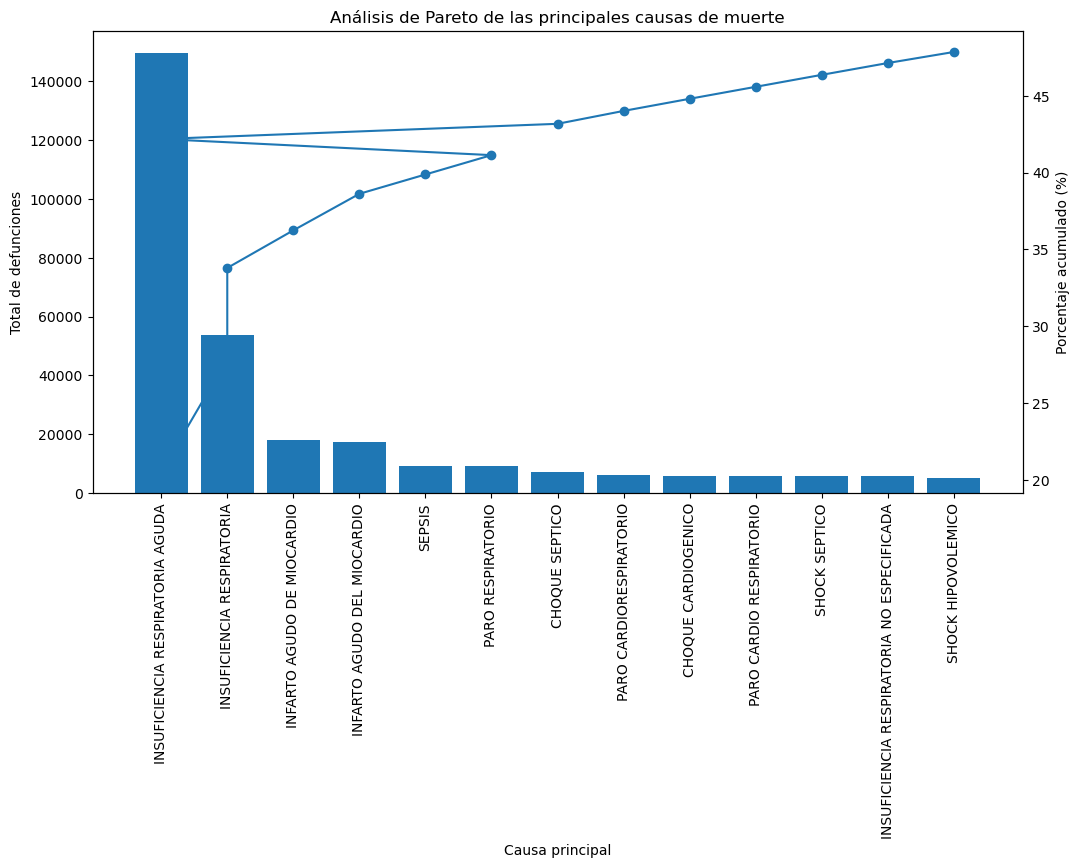

In [135]:
import matplotlib.pyplot as plt

top_pareto = tabla_pareto_causas.head(15)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    top_pareto["causa_principal"],
    top_pareto["total_defunciones"]
)

ax1.set_xlabel("Causa principal")
ax1.set_ylabel("Total de defunciones")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()
ax2.plot(
    top_pareto["causa_principal"],
    top_pareto["porcentaje_acumulado"],
    marker="o"
)

ax2.set_ylabel("Porcentaje acumulado (%)")

plt.title("Análisis de Pareto de las principales causas de muerte")
plt.show()

In [199]:
df_modelo_edad = df_final_peru.copy()

df_modelo_edad["objetivo_anciano"] = df_modelo_edad["grupo_edad"].apply(
    lambda x: 1 if "Anciano" in str(x) else 0
)

df_modelo_edad["objetivo_anciano"].value_counts(dropna=False)

objetivo_anciano
1    619762
0    266296
Name: count, dtype: int64

In [201]:
top_causas = (
    df_modelo_edad["causa_principal"]
    .value_counts()
    .head(15)
    .index
)

df_modelo_edad["causa_grupo"] = df_modelo_edad["causa_principal"].apply(
    lambda x: x if x in top_causas else "OTRAS CAUSAS"
)

In [203]:
variables_modelo = [
    "sexo",
    "region_natural",
    "departamento_domicilio",
    "tipo_seguro",
    "tipo_lugar",
    "necropsia",
    "causa_grupo"
]

df_modelo_edad = df_modelo_edad[
    variables_modelo + ["objetivo_anciano"]
].dropna()

print(df_modelo_edad.shape)
df_modelo_edad.head()

(886058, 8)


,sexo,region_natural,departamento_domicilio,tipo_seguro,tipo_lugar,necropsia,causa_grupo,objetivo_anciano
0,MASCULINO,COSTA,LIMA,ESSALUD,EESS,NO SE REALIZO NECROPSIA,SHOCK SEPTICO,0
1,MASCULINO,COSTA,AREQUIPA,SIS,VIA PUBLICA,SI SE REALIZO NECROPSIA,OTRAS CAUSAS,0
2,MASCULINO,COSTA,LIMA,ESSALUD,EESS,NO SE REALIZO NECROPSIA,FALLA ORGANICA MULTIPLE,1
3,FEMENINO,COSTA,ANCASH,SIS,DOMICILIO,NO SE REALIZO NECROPSIA,OTRAS CAUSAS,1
4,FEMENINO,COSTA,AREQUIPA,SIS,EESS,NO SE REALIZO NECROPSIA,OTRAS CAUSAS,1


In [205]:
X = pd.get_dummies(
    df_modelo_edad[variables_modelo],
    drop_first=True
)

y = df_modelo_edad["objetivo_anciano"]

print("Tamaño de X:", X.shape)
print("Distribución de y:")
print(y.value_counts())

Tamaño de X: (886058, 63)
Distribución de y:
objetivo_anciano
1    619762
0    266296
Name: count, dtype: int64


In [207]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (620240, 63)
Prueba: (265818, 63)


In [209]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modelo_arbol_edad = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

modelo_arbol_edad.fit(X_train, y_train)

y_pred = modelo_arbol_edad.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No anciano", "Anciano"],
        zero_division=0
    )
)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6790134603375242

Reporte de clasificación:
              precision    recall  f1-score   support

  No anciano       0.47      0.55      0.51     79889
     Anciano       0.79      0.73      0.76    185929

    accuracy                           0.68    265818
   macro avg       0.63      0.64      0.63    265818
weighted avg       0.70      0.68      0.69    265818


Matriz de confusión:
[[ 44089  35800]
 [ 49524 136405]]


In [211]:
importancia_variables_edad = pd.DataFrame({
    "variable": X.columns,
    "importancia": modelo_arbol_edad.feature_importances_
}).sort_values("importancia", ascending=False)

importancia_variables_edad.head(15)

,variable,importancia
46,necropsia_SI SE REALIZO NECROPSIA,0.408985
40,tipo_lugar_DOMICILIO,0.259958
37,tipo_seguro_SIS,0.201824
30,tipo_seguro_IGNORADO,0.060000
3,region_natural_SELVA,0.021125
1,sexo_MASCULINO,0.013933
55,causa_grupo_OTRAS CAUSAS,0.010524
41,tipo_lugar_EESS,0.009401
4,region_natural_SIERRA,0.005112
39,tipo_seguro_USUARIO,0.004958


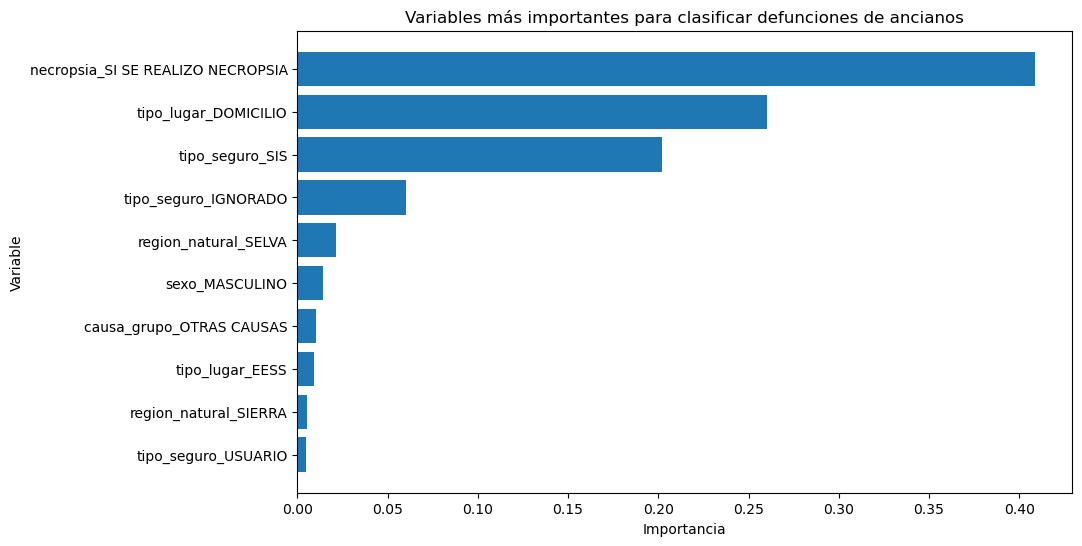

In [213]:
import matplotlib.pyplot as plt

top_importancia = importancia_variables_edad.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_importancia["variable"],
    top_importancia["importancia"]
)
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Variables más importantes para clasificar defunciones de ancianos")
plt.gca().invert_yaxis()
plt.show()

In [221]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

reporte_dict = classification_report(
    y_test,
    y_pred,
    target_names=["No anciano", "Anciano"],
    output_dict=True,
    zero_division=0
)

metricas_modelo_edad = pd.DataFrame(reporte_dict).transpose().reset_index()

metricas_modelo_edad = metricas_modelo_edad.rename(columns={
    "index": "clase"
})
metricas_modelo_edad["modelo"] = "Árbol de decisión - clasificación anciano/no anciano"

metricas_modelo_edad["accuracy_general"] = accuracy_score(y_test, y_pred)

metricas_modelo_edad

,clase,precision,recall,f1-score,support,modelo,accuracy_general
0,No anciano,0.470971,0.551878,0.508225,79889.000000,Árbol de decisión - clasificación anciano/no a...,0.679013
1,Anciano,0.792108,0.733640,0.761754,185929.000000,Árbol de decisión - clasificación anciano/no a...,0.679013
2,accuracy,0.679013,0.679013,0.679013,0.679013,Árbol de decisión - clasificación anciano/no a...,0.679013
3,macro avg,0.631540,0.642759,0.634989,265818.000000,Árbol de decisión - clasificación anciano/no a...,0.679013
4,weighted avg,0.695594,0.679013,0.685558,265818.000000,Árbol de decisión - clasificación anciano/no a...,0.679013


In [219]:
matriz = confusion_matrix(y_test, y_pred)

matriz_confusion_edad = pd.DataFrame(
    matriz,
    index=["Real_No_anciano", "Real_Anciano"],
    columns=["Predicho_No_anciano", "Predicho_Anciano"]
).reset_index()

matriz_confusion_edad = matriz_confusion_edad.rename(columns={
    "index": "clase_real"
})

matriz_confusion_edad

,clase_real,Predicho_No_anciano,Predicho_Anciano
0,Real_No_anciano,44089,35800
1,Real_Anciano,49524,136405


In [223]:
importancia_variables_edad_top = importancia_variables_edad.head(15).copy()

importancia_variables_edad_top["modelo"] = "Árbol de decisión - clasificación anciano/no anciano"

importancia_variables_edad_top

,variable,importancia,modelo
46,necropsia_SI SE REALIZO NECROPSIA,0.408985,Árbol de decisión - clasificación anciano/no a...
40,tipo_lugar_DOMICILIO,0.259958,Árbol de decisión - clasificación anciano/no a...
37,tipo_seguro_SIS,0.201824,Árbol de decisión - clasificación anciano/no a...
30,tipo_seguro_IGNORADO,0.060000,Árbol de decisión - clasificación anciano/no a...
3,region_natural_SELVA,0.021125,Árbol de decisión - clasificación anciano/no a...
1,sexo_MASCULINO,0.013933,Árbol de decisión - clasificación anciano/no a...
55,causa_grupo_OTRAS CAUSAS,0.010524,Árbol de decisión - clasificación anciano/no a...
41,tipo_lugar_EESS,0.009401,Árbol de decisión - clasificación anciano/no a...
4,region_natural_SIERRA,0.005112,Árbol de decisión - clasificación anciano/no a...
39,tipo_seguro_USUARIO,0.004958,Árbol de decisión - clasificación anciano/no a...


In [227]:
df_segmentacion_departamento

,departamento,region_natural,total_defunciones,nivel_defunciones
14,LIMA,COSTA,329091,Muy alta concentración
12,LA LIBERTAD,COSTA,56920,Muy alta concentración
19,PIURA,COSTA,47606,Muy alta concentración
3,AREQUIPA,COSTA,46934,Muy alta concentración
11,JUNIN,SIERRA,39279,Muy alta concentración
20,PUNO,SIERRA,38996,Muy alta concentración
1,ANCASH,COSTA,38976,Alta concentración
7,CUSCO,SIERRA,35401,Alta concentración
10,ICA,COSTA,32441,Alta concentración
5,CAJAMARCA,SIERRA,25581,Alta concentración


In [229]:
df_segmentacion_departamento = df_segmentacion_departamento.sort_values(
    "total_defunciones",
    ascending=False
).reset_index(drop=True)

df_segmentacion_departamento

,departamento,region_natural,total_defunciones,nivel_defunciones
0,LIMA,COSTA,329091,Muy alta concentración
1,LA LIBERTAD,COSTA,56920,Muy alta concentración
2,PIURA,COSTA,47606,Muy alta concentración
3,AREQUIPA,COSTA,46934,Muy alta concentración
4,JUNIN,SIERRA,39279,Muy alta concentración
5,PUNO,SIERRA,38996,Muy alta concentración
6,ANCASH,COSTA,38976,Alta concentración
7,CUSCO,SIERRA,35401,Alta concentración
8,ICA,COSTA,32441,Alta concentración
9,CAJAMARCA,SIERRA,25581,Alta concentración


In [231]:
print("Total de departamentos segmentados:", df_segmentacion_departamento["departamento"].nunique())

display(
    df_segmentacion_departamento["nivel_defunciones"].value_counts()
)

Total de departamentos segmentados: 25


nivel_defunciones
Baja concentración        7
Media concentración       6
Alta concentración        6
Muy alta concentración    6
Name: count, dtype: int64

In [233]:
tablas_necesarias = {
    "df_final_peru": df_final_peru,
    "df_segmentacion_departamento": df_segmentacion_departamento,
    "tabla_pareto_causas": tabla_pareto_causas,
    "metricas_modelo_edad": metricas_modelo_edad,
    "matriz_confusion_edad": matriz_confusion_edad,
    "importancia_variables_edad_top": importancia_variables_edad_top,
    "ubigeo": ubigeo,
    "region": region
}

for nombre, tabla in tablas_necesarias.items():
    print(nombre, tabla.shape)

df_final_peru (886058, 41)
df_segmentacion_departamento (25, 4)
tabla_pareto_causas (56853, 5)
metricas_modelo_edad (5, 7)
matriz_confusion_edad (2, 3)
importancia_variables_edad_top (15, 3)
ubigeo (1873, 7)
region (25, 3)


In [235]:
# Copias para carga a PostgreSQL

fact_defunciones = df_final_peru.copy()
dim_ubigeo = ubigeo.copy()
dim_region_natural = region.copy()
segmentacion_departamentos = df_segmentacion_departamento.copy()
pareto_causas = tabla_pareto_causas.copy()
metricas_arbol_edad = metricas_modelo_edad.copy()
matriz_confusion_arbol_edad = matriz_confusion_edad.copy()
importancia_arbol_edad = importancia_variables_edad_top.copy()

# Limpiar nombres de columnas
fact_defunciones.columns = [limpiar_nombre_columna(col) for col in fact_defunciones.columns]
dim_ubigeo.columns = [limpiar_nombre_columna(col) for col in dim_ubigeo.columns]
dim_region_natural.columns = [limpiar_nombre_columna(col) for col in dim_region_natural.columns]
segmentacion_departamentos.columns = [limpiar_nombre_columna(col) for col in segmentacion_departamentos.columns]
pareto_causas.columns = [limpiar_nombre_columna(col) for col in pareto_causas.columns]
metricas_arbol_edad.columns = [limpiar_nombre_columna(col) for col in metricas_arbol_edad.columns]
matriz_confusion_arbol_edad.columns = [limpiar_nombre_columna(col) for col in matriz_confusion_arbol_edad.columns]
importancia_arbol_edad.columns = [limpiar_nombre_columna(col) for col in importancia_arbol_edad.columns]

# Convertir columnas tipo categoría a texto
for tabla in [
    fact_defunciones,
    segmentacion_departamentos,
    pareto_causas,
    metricas_arbol_edad,
    matriz_confusion_arbol_edad,
    importancia_arbol_edad
]:
    for col in tabla.columns:
        if str(tabla[col].dtype) == "category":
            tabla[col] = tabla[col].astype(str)

print("Tablas preparadas para PostgreSQL")

Tablas preparadas para PostgreSQL


In [237]:
with engine.begin() as conn:
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS staging;"))
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS dw;"))
    conn.execute(text("CREATE SCHEMA IF NOT EXISTS mart;"))

print("Esquemas verificados correctamente")

Esquemas verificados correctamente


In [239]:
dim_ubigeo.to_sql(
    "dim_ubigeo",
    engine,
    schema="dw",
    if_exists="replace",
    index=False
)

dim_region_natural.to_sql(
    "dim_region_natural",
    engine,
    schema="dw",
    if_exists="replace",
    index=False
)

print("Dimensiones cargadas correctamente en dw")

Dimensiones cargadas correctamente en dw


In [241]:
fact_defunciones.to_sql(
    "fact_defunciones",
    engine,
    schema="dw",
    if_exists="replace",
    index=False,
    chunksize=500,
    method="multi"
)

print("Tabla dw.fact_defunciones cargada correctamente")

Tabla dw.fact_defunciones cargada correctamente


In [243]:
segmentacion_departamentos.to_sql(
    "segmentacion_departamentos",
    engine,
    schema="mart",
    if_exists="replace",
    index=False
)

pareto_causas.to_sql(
    "pareto_causas",
    engine,
    schema="mart",
    if_exists="replace",
    index=False
)

metricas_arbol_edad.to_sql(
    "metricas_arbol_edad",
    engine,
    schema="mart",
    if_exists="replace",
    index=False
)

matriz_confusion_arbol_edad.to_sql(
    "matriz_confusion_arbol_edad",
    engine,
    schema="mart",
    if_exists="replace",
    index=False
)

importancia_arbol_edad.to_sql(
    "importancia_arbol_edad",
    engine,
    schema="mart",
    if_exists="replace",
    index=False
)

print("Tablas analíticas cargadas correctamente en mart")

Tablas analíticas cargadas correctamente en mart


In [245]:
with engine.begin() as conn:
    conn.execute(text("""
        INSERT INTO dw.control_etl (
            nombre_proceso,
            estado,
            observacion
        )
        VALUES (
            'Carga de datos transformados a PostgreSQL',
            'Correcto',
            'Se cargaron la tabla fact_defunciones, dimensiones y tablas analíticas para dashboard.'
        );
    """))

print("Registro ETL insertado correctamente")

Registro ETL insertado correctamente


In [247]:
consulta_tablas = """
SELECT 
    table_schema,
    table_name
FROM information_schema.tables
WHERE table_schema IN ('dw', 'mart')
ORDER BY table_schema, table_name;
"""

tablas_postgres = pd.read_sql(consulta_tablas, engine)

tablas_postgres

,table_schema,table_name
0,dw,control_etl
1,dw,dim_region_natural
2,dw,dim_ubigeo
3,dw,fact_defunciones
4,mart,importancia_arbol_edad
5,mart,matriz_confusion_arbol_edad
6,mart,metricas_arbol_edad
7,mart,pareto_causas
8,mart,segmentacion_departamentos


In [249]:
consultas_conteo = {
    "dw.fact_defunciones": "SELECT COUNT(*) AS total FROM dw.fact_defunciones;",
    "dw.dim_ubigeo": "SELECT COUNT(*) AS total FROM dw.dim_ubigeo;",
    "dw.dim_region_natural": "SELECT COUNT(*) AS total FROM dw.dim_region_natural;",
    "mart.segmentacion_departamentos": "SELECT COUNT(*) AS total FROM mart.segmentacion_departamentos;",
    "mart.pareto_causas": "SELECT COUNT(*) AS total FROM mart.pareto_causas;",
    "mart.metricas_arbol_edad": "SELECT COUNT(*) AS total FROM mart.metricas_arbol_edad;",
    "mart.matriz_confusion_arbol_edad": "SELECT COUNT(*) AS total FROM mart.matriz_confusion_arbol_edad;",
    "mart.importancia_arbol_edad": "SELECT COUNT(*) AS total FROM mart.importancia_arbol_edad;"
}

for nombre, consulta in consultas_conteo.items():
    resultado = pd.read_sql(consulta, engine)
    print(nombre, ":", resultado.iloc[0, 0])

dw.fact_defunciones : 886058
dw.dim_ubigeo : 1873
dw.dim_region_natural : 25
mart.segmentacion_departamentos : 25
mart.pareto_causas : 56853
mart.metricas_arbol_edad : 5
mart.matriz_confusion_arbol_edad : 2
mart.importancia_arbol_edad : 15


In [251]:
with engine.begin() as conn:

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_defunciones_por_anio AS
        SELECT 
            anio,
            COUNT(*) AS total_defunciones
        FROM dw.fact_defunciones
        GROUP BY anio
        ORDER BY anio;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_defunciones_por_mes AS
        SELECT 
            anio,
            mes,
            nombre_mes,
            periodo,
            COUNT(*) AS total_defunciones
        FROM dw.fact_defunciones
        GROUP BY anio, mes, nombre_mes, periodo
        ORDER BY anio, mes;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_defunciones_por_departamento AS
        SELECT 
            departamento_clean AS departamento,
            region_natural,
            COUNT(*) AS total_defunciones
        FROM dw.fact_defunciones
        GROUP BY departamento_clean, region_natural
        ORDER BY total_defunciones DESC;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_defunciones_por_region_natural AS
        SELECT 
            region_natural,
            COUNT(*) AS total_defunciones
        FROM dw.fact_defunciones
        GROUP BY region_natural
        ORDER BY total_defunciones DESC;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_defunciones_por_sexo AS
        SELECT 
            sexo,
            COUNT(*) AS total_defunciones
        FROM dw.fact_defunciones
        GROUP BY sexo
        ORDER BY total_defunciones DESC;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_defunciones_por_grupo_edad AS
        SELECT 
            grupo_edad,
            COUNT(*) AS total_defunciones
        FROM dw.fact_defunciones
        GROUP BY grupo_edad
        ORDER BY total_defunciones DESC;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_defunciones_por_sexo_grupo_edad AS
        SELECT 
            sexo,
            grupo_edad,
            COUNT(*) AS total_defunciones
        FROM dw.fact_defunciones
        GROUP BY sexo, grupo_edad
        ORDER BY sexo, total_defunciones DESC;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_principales_causas_muerte AS
        SELECT 
            causa_principal,
            codigo_cie_principal,
            COUNT(*) AS total_defunciones
        FROM dw.fact_defunciones
        WHERE causa_principal IS NOT NULL
        GROUP BY causa_principal, codigo_cie_principal
        ORDER BY total_defunciones DESC;
    """))

print("Vistas principales creadas correctamente")

Vistas principales creadas correctamente


In [253]:
with engine.begin() as conn:

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_segmentacion_departamentos AS
        SELECT 
            departamento,
            region_natural,
            total_defunciones,
            nivel_defunciones
        FROM mart.segmentacion_departamentos
        ORDER BY total_defunciones DESC;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_pareto_causas AS
        SELECT 
            causa_principal,
            codigo_cie_principal,
            total_defunciones,
            porcentaje,
            porcentaje_acumulado
        FROM mart.pareto_causas
        ORDER BY total_defunciones DESC;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_metricas_modelo_edad AS
        SELECT *
        FROM mart.metricas_arbol_edad;
    """))

    conn.execute(text("""
        CREATE OR REPLACE VIEW mart.vw_importancia_modelo_edad AS
        SELECT *
        FROM mart.importancia_arbol_edad
        ORDER BY importancia DESC;
    """))

print("Vistas analíticas creadas correctamente")

Vistas analíticas creadas correctamente


In [255]:
vistas_validacion = {
    "Defunciones por año": "SELECT * FROM mart.vw_defunciones_por_anio;",
    "Top departamentos": "SELECT * FROM mart.vw_defunciones_por_departamento LIMIT 10;",
    "Región natural": "SELECT * FROM mart.vw_defunciones_por_region_natural;",
    "Sexo y grupo edad": "SELECT * FROM mart.vw_defunciones_por_sexo_grupo_edad LIMIT 10;",
    "Pareto causas": "SELECT * FROM mart.vw_pareto_causas LIMIT 10;",
    "Segmentación departamentos": "SELECT * FROM mart.vw_segmentacion_departamentos LIMIT 10;",
    "Importancia modelo edad": "SELECT * FROM mart.vw_importancia_modelo_edad LIMIT 10;"
}

for nombre, consulta in vistas_validacion.items():
    print("\n", nombre)
    display(pd.read_sql(consulta, engine))


 Defunciones por año


,anio,total_defunciones
0,2019,114378
1,2020,215784
2,2021,247718
3,2022,158140
4,2023,110432
5,2024,39606



 Top departamentos


,departamento,region_natural,total_defunciones
0,LIMA,COSTA,329091
1,LA LIBERTAD,COSTA,56920
2,PIURA,COSTA,47606
3,AREQUIPA,COSTA,46934
4,JUNIN,SIERRA,39279
5,PUNO,SIERRA,38996
6,ANCASH,COSTA,38976
7,CUSCO,SIERRA,35401
8,ICA,COSTA,32441
9,CAJAMARCA,SIERRA,25581



 Región natural


...

,causa_principal,codigo_cie_principal,total_defunciones,porcentaje,porcentaje_acumulado
0,INSUFICIENCIA RESPIRATORIA AGUDA,J960,149620,20.50,20.50
1,INSUFICIENCIA RESPIRATORIA,J960,53809,7.37,27.87
2,INSUFICIENCIA RESPIRATORIA,J969,43227,5.92,33.79
3,INFARTO AGUDO DE MIOCARDIO,I219,17861,2.45,36.24
4,INFARTO AGUDO DEL MIOCARDIO,I219,17382,2.38,38.62
5,SEPSIS,A419,9201,1.26,39.88
6,PARO RESPIRATORIO,R092,9171,1.26,41.14
7,INSUFICIENCIA RESPIRATORIA AGUDA,J969,7669,1.05,42.19
8,CHOQUE SEPTICO,R572,7199,0.99,43.18
9,PARO CARDIORESPIRATORIO,I469,6129,0.84,44.02



 Segmentación departamentos


,departamento,region_natural,total_defunciones,nivel_defunciones
0,LIMA,COSTA,329091,Muy alta concentración
1,LA LIBERTAD,COSTA,56920,Muy alta concentración
2,PIURA,COSTA,47606,Muy alta concentración
3,AREQUIPA,COSTA,46934,Muy alta concentración
4,JUNIN,SIERRA,39279,Muy alta concentración
5,PUNO,SIERRA,38996,Muy alta concentración
6,ANCASH,COSTA,38976,Alta concentración
7,CUSCO,SIERRA,35401,Alta concentración
8,ICA,COSTA,32441,Alta concentración
9,CAJAMARCA,SIERRA,25581,Alta concentración



 Importancia modelo edad


,variable,importancia,modelo
0,necropsia_SI SE REALIZO NECROPSIA,0.408985,Árbol de decisión - clasificación anciano/no a...
1,tipo_lugar_DOMICILIO,0.259958,Árbol de decisión - clasificación anciano/no a...
2,tipo_seguro_SIS,0.201824,Árbol de decisión - clasificación anciano/no a...
3,tipo_seguro_IGNORADO,0.060000,Árbol de decisión - clasificación anciano/no a...
4,region_natural_SELVA,0.021125,Árbol de decisión - clasificación anciano/no a...
5,sexo_MASCULINO,0.013933,Árbol de decisión - clasificación anciano/no a...
6,causa_grupo_OTRAS CAUSAS,0.010524,Árbol de decisión - clasificación anciano/no a...
7,tipo_lugar_EESS,0.009401,Árbol de decisión - clasificación anciano/no a...
8,region_natural_SIERRA,0.005112,Árbol de decisión - clasificación anciano/no a...
9,tipo_seguro_USUARIO,0.004958,Árbol de decisión - clasificación anciano/no a...
